In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Romanized Pashto Dataset: Comprehensive Research Analysis

## 1. Setup and Data Loading

In [2]:
import pandas as pd

In [3]:
file_path = '/content/drive/MyDrive/big_file - combined_data.csv'
df = pd.read_csv(file_path)
display(df.head())

,text,label
0,"Da khu ghazab kar dey, ATM bya cash na wo.",Negative
1,Sta jawab khu university lecture na kam nishta...,Negative
2,"Sabas, da khu top class service da, order bya ...",Negative
3,"Bya de kamal wo, project deadline bya nazde da...",Negative
4,"Da khu award wor le pakar dey, ATM bya cash na...",Negative


## 2. Overall Dataset Statistics

In [4]:
print(f"Total Records (rows): {df.shape[0]}")
print(f"Number of Columns: {df.shape[1]}")

Total Records (rows): 8239
Number of Columns: 2


In [5]:
print("\nDataset Inspection (Datatypes and Missing Values):")
df.info()


Dataset Inspection (Datatypes and Missing Values):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8239 entries, 0 to 8238
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    8239 non-null   object
 1   label   8239 non-null   object
dtypes: object(2)
memory usage: 128.9+ KB


In [6]:
print(f"\nUnique Sentences: {df['text'].nunique()}")
duplicate_rate = (df.duplicated().sum() / len(df)) * 100
print(f"Duplicate Rate: {duplicate_rate:.2f}%")


Unique Sentences: 7095
Duplicate Rate: 13.67%


In [7]:
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))
total_words = df['word_count'].sum()
print(f"Total Words/Tokens: {total_words}")

Total Words/Tokens: 47241


In [8]:
avg_sentence_length = df['word_count'].mean()
min_sentence_length = df['word_count'].min()
max_sentence_length = df['word_count'].max()

print(f"Average Sentence Length (words): {avg_sentence_length:.2f}")
print(f"Minimum Sentence Length (words): {min_sentence_length}")
print(f"Maximum Sentence Length (words): {max_sentence_length}")

Average Sentence Length (words): 5.73
Minimum Sentence Length (words): 1
Maximum Sentence Length (words): 17


In [9]:
print("\nSentiment Distribution (Raw):")
display(df['label'].value_counts())


Sentiment Distribution (Raw):


,count
label,
0,1850
2,1812
1,1677
Neutral,1283
Negative,888
Positive,729


In [10]:
# Standardize sentiment labels based on user's clarification:
# 0: Positive, 1: Negative, 2: Neutral
df['label'] = df['label'].astype(str)
label_mapping = {
    '0': 'Positive',
    '1': 'Negative',
    '2': 'Neutral'
}
df['label'] = df['label'].replace(label_mapping)

print("Sentiment Distribution (Consolidated):")
display(df['label'].value_counts())

Sentiment Distribution (Consolidated):


,count
label,
Neutral,3095
Positive,2579
Negative,2565


In [11]:
import re

def clean_text(text):
    text = str(text).lower()  # Convert to lowercase
    text = re.sub(r'[^a-z0-9\s]', '', text)  # Remove punctuation and special characters
    text = re.sub(r'\s+', ' ', text).strip()  # Remove extra spaces
    return text

df['cleaned_text'] = df['text'].apply(clean_text)
display(df[['text', 'cleaned_text', 'label']].head())

,text,cleaned_text,label
0,"Da khu ghazab kar dey, ATM bya cash na wo.",da khu ghazab kar dey atm bya cash na wo,Negative
1,Sta jawab khu university lecture na kam nishta...,sta jawab khu university lecture na kam nishta...,Negative
2,"Sabas, da khu top class service da, order bya ...",sabas da khu top class service da order bya gh...,Negative
3,"Bya de kamal wo, project deadline bya nazde da...",bya de kamal wo project deadline bya nazde da ...,Negative
4,"Da khu award wor le pakar dey, ATM bya cash na...",da khu award wor le pakar dey atm bya cash na wo,Negative


## 4. Vocabulary and Character-Level Analysis

In [13]:
import nltk
from nltk.corpus import stopwords
from collections import Counter

# Download necessary NLTK data (if not already downloaded)
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

all_words = ' '.join(df['cleaned_text']).split()

# Filter out stopwords if desired (optional for Pashto, but good practice)
# Pashto stopwords might not be directly available in NLTK,
# so we proceed without explicit Pashto stopwords for now.
# If a Pashto stopword list is available, it can be added here.

word_counts = Counter(all_words)

print("\nTop 20 Most Frequent Words (Linguistic Tokens):")
display(word_counts.most_common(20))

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.



Top 20 Most Frequent Words (Linguistic Tokens):


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


[('pa', 2306),
 ('da', 1973),
 ('ke', 1790),
 ('wo', 1451),
 ('wa', 1001),
 ('na', 987),
 ('kho', 796),
 ('ta', 762),
 ('sho', 594),
 ('der', 513),
 ('shwa', 474),
 ('dey', 443),
 ('bya', 388),
 ('me', 382),
 ('dera', 372),
 ('kra', 357),
 ('de', 324),
 ('sara', 311),
 ('che', 301),
 ('khu', 295)]

/tmp/ipykernel_2291/581596579.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[item[0] for item in char_unigrams.most_common(20)], y=[item[1] for item in char_unigrams.most_common(20)], palette='viridis')


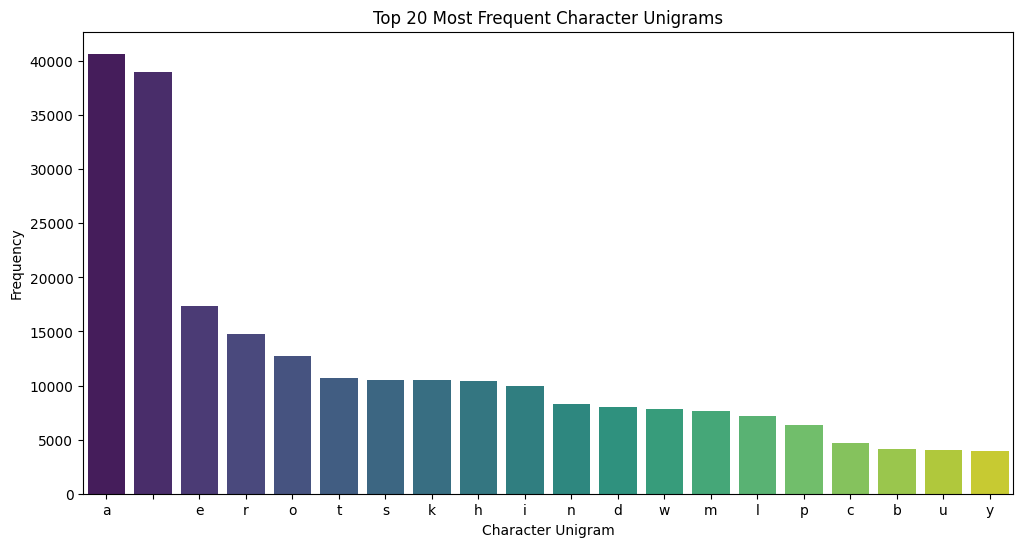

/tmp/ipykernel_2291/581596579.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[item[0] for item in char_bigrams.most_common(20)], y=[item[1] for item in char_bigrams.most_common(20)], palette='magma')


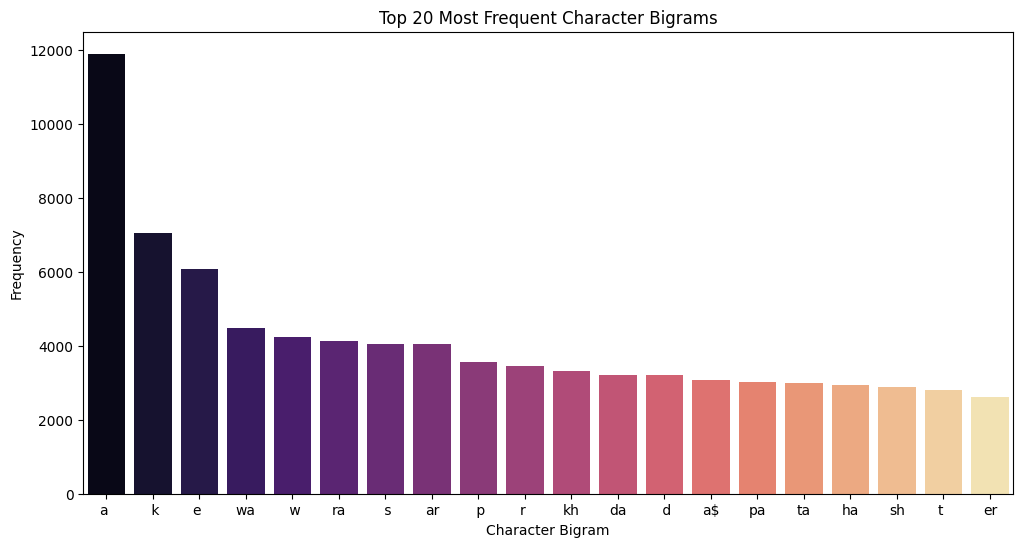

/tmp/ipykernel_2291/581596579.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[item[0] for item in char_trigrams.most_common(20)], y=[item[1] for item in char_trigrams.most_common(20)], palette='plasma')


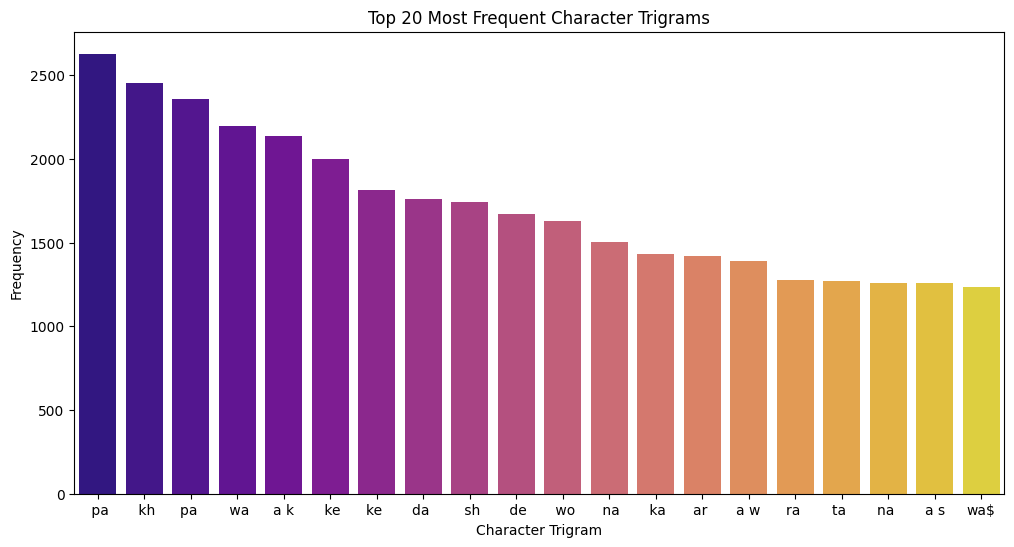

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Function to get n-grams from text
def get_ngrams(text, n, char_level=False):
    if char_level:
        # For character n-grams, treat the entire text as a sequence of characters
        # Add start/end markers for character n-grams to capture beginning/end patterns
        text = '^' + text + '$'
        return [text[i:i+n] for i in range(len(text)-n+1)]
    else:
        # For word n-grams
        words = text.split()
        return [' '.join(words[i:i+n]) for i in range(len(words)-n+1)]

# Character-level Unigrams
all_chars_text = ''.join(df['cleaned_text'])
char_unigrams = Counter(get_ngrams(all_chars_text, 1, char_level=True))

plt.figure(figsize=(12, 6))
sns.barplot(x=[item[0] for item in char_unigrams.most_common(20)], y=[item[1] for item in char_unigrams.most_common(20)], palette='viridis')
plt.title('Top 20 Most Frequent Character Unigrams')
plt.xlabel('Character Unigram')
plt.ylabel('Frequency')
plt.show()

# Character-level Bigrams
char_bigrams = Counter([bg for text in df['cleaned_text'] for bg in get_ngrams(text, 2, char_level=True)])

plt.figure(figsize=(12, 6))
sns.barplot(x=[item[0] for item in char_bigrams.most_common(20)], y=[item[1] for item in char_bigrams.most_common(20)], palette='magma')
plt.title('Top 20 Most Frequent Character Bigrams')
plt.xlabel('Character Bigram')
plt.ylabel('Frequency')
plt.show()

# Character-level Trigrams
char_trigrams = Counter([tg for text in df['cleaned_text'] for tg in get_ngrams(text, 3, char_level=True)])

plt.figure(figsize=(12, 6))
sns.barplot(x=[item[0] for item in char_trigrams.most_common(20)], y=[item[1] for item in char_trigrams.most_common(20)], palette='plasma')
plt.title('Top 20 Most Frequent Character Trigrams')
plt.xlabel('Character Trigram')
plt.ylabel('Frequency')
plt.show()

### Distribution of Sentence Length (Words)

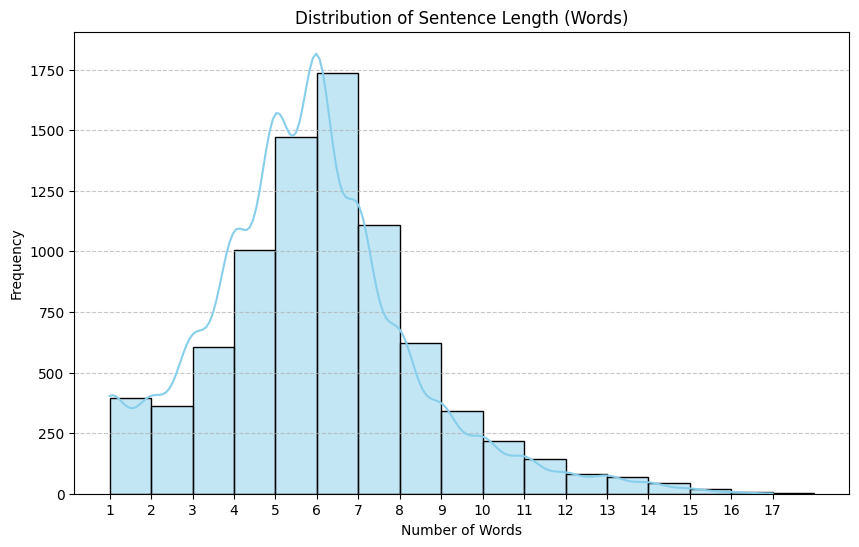

In [15]:
plt.figure(figsize=(10, 6))
sns.histplot(df['word_count'], bins=range(1, df['word_count'].max() + 2), kde=True, color='skyblue')
plt.title('Distribution of Sentence Length (Words)')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.xticks(range(1, df['word_count'].max() + 1))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## 5. Sentiment Analysis and Cleaning Pipeline Impact

### Sentiment Distribution (Consolidated)

Sentiment Distribution (Consolidated):


,count
label,
Neutral,3095
Positive,2579
Negative,2565


/tmp/ipykernel_2291/1726504337.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette='viridis')


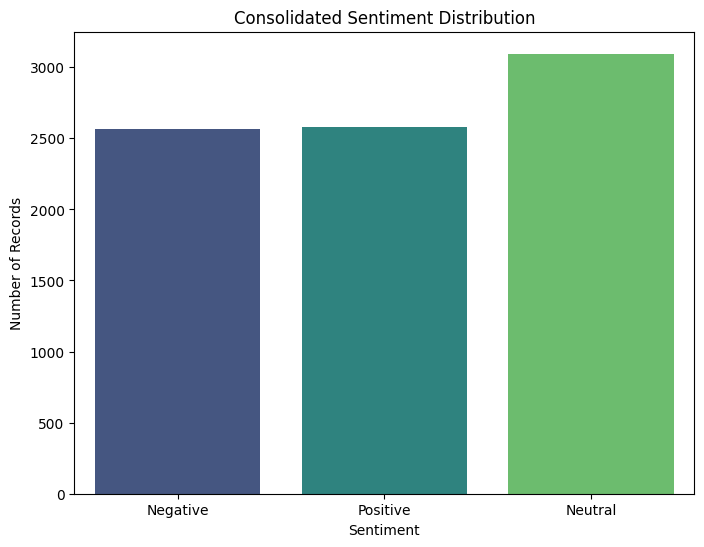

In [16]:
print("Sentiment Distribution (Consolidated):")
display(df['label'].value_counts())

plt.figure(figsize=(8, 6))
sns.countplot(x='label', data=df, palette='viridis')
plt.title('Consolidated Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Records')
plt.show()

### Sentence Length (Words) by Sentiment

/tmp/ipykernel_2291/2466813517.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y='word_count', data=df, palette='magma')


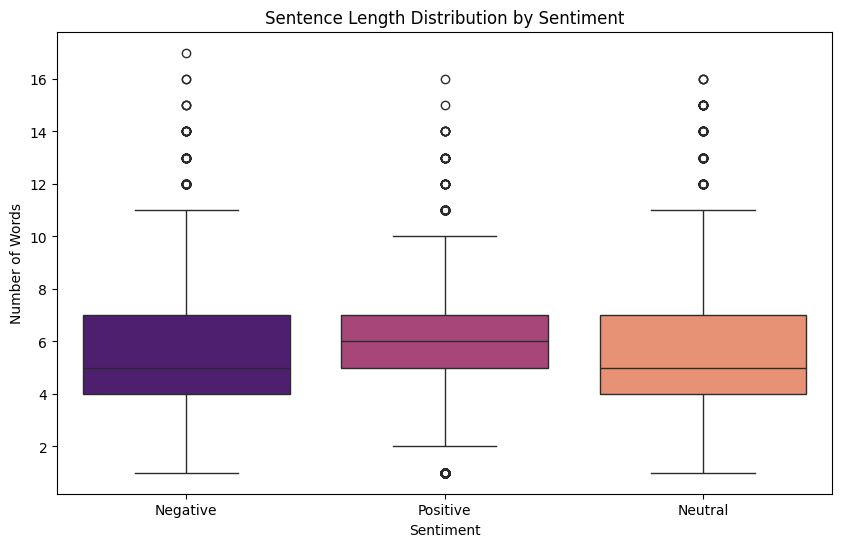

In [17]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='label', y='word_count', data=df, palette='magma')
plt.title('Sentence Length Distribution by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Number of Words')
plt.show()

### Data Cleaning Pipeline Impact

Original Text Length Descriptive Statistics:


,original_text_length
count,8239.000000
mean,32.488652
std,13.670980
min,1.000000
25%,25.000000
50%,32.000000
75%,39.000000
max,100.000000


Cleaned Text Length Descriptive Statistics:


,cleaned_text_length
count,8239.000000
mean,30.240199
std,13.417202
min,0.000000
25%,23.000000
50%,30.000000
75%,37.000000
max,90.000000


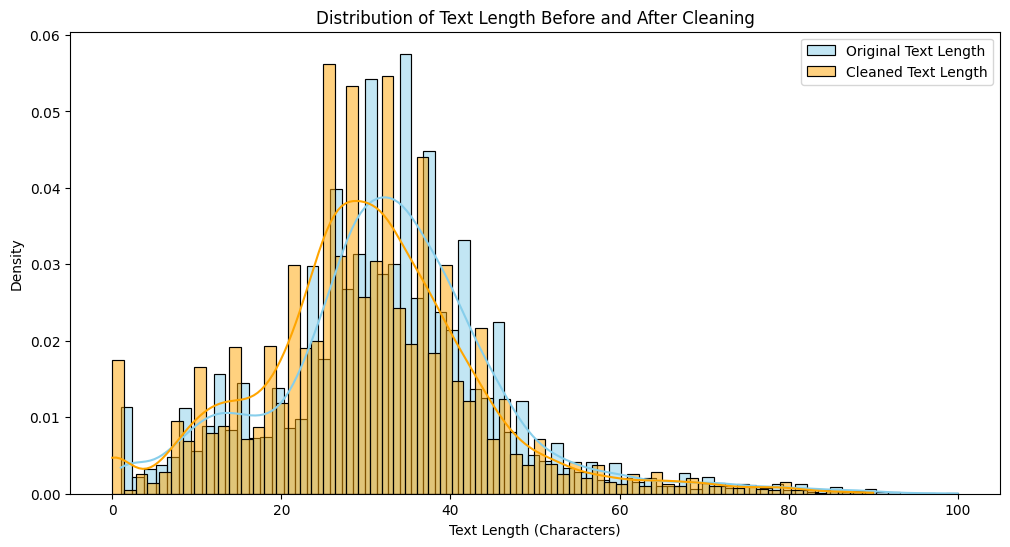


Examples of text before and after cleaning:


,text,cleaned_text
3702,Service zabardast wa kho delivery der sho.,service zabardast wa kho delivery der sho
3135,Riwayati music zorr larl kho dilchasp wo.,riwayati music zorr larl kho dilchasp wo
1163,Dalta hich sok pate ma keezi!,dalta hich sok pate ma keezi
1047,"Za ba minat na kawam, mehrbani wa ka rasha.",za ba minat na kawam mehrbani wa ka rasha
625,Ta pohegey che da bill senga pay kegi online?,ta pohegey che da bill senga pay kegi online


In [18]:
# Compare original and cleaned text length distributions
df['original_text_length'] = df['text'].apply(len)
df['cleaned_text_length'] = df['cleaned_text'].apply(len)

print("Original Text Length Descriptive Statistics:")
display(df['original_text_length'].describe())

print("Cleaned Text Length Descriptive Statistics:")
display(df['cleaned_text_length'].describe())

# Visualize the distribution of text lengths before and after cleaning
plt.figure(figsize=(12, 6))
sns.histplot(df['original_text_length'], color='skyblue', label='Original Text Length', kde=True, stat='density', alpha=0.5)
sns.histplot(df['cleaned_text_length'], color='orange', label='Cleaned Text Length', kde=True, stat='density', alpha=0.5)
plt.title('Distribution of Text Length Before and After Cleaning')
plt.xlabel('Text Length (Characters)')
plt.ylabel('Density')
plt.legend()
plt.show()

print("\nExamples of text before and after cleaning:")
display(df[['text', 'cleaned_text']].sample(5))

## 6. Final Research Markdown Report

# Romanized Pashto Dataset: Comprehensive Research Analysis

This report details a comprehensive research analysis performed on a Romanized Pashto dataset, covering various aspects from basic statistics to sentiment and linguistic analysis, and evaluating the impact of a data cleaning pipeline.

## 1. Overall Dataset Statistics

This section provides an overview of the dataset's basic characteristics, including its size, duplication rate, and fundamental textual properties like word and sentence counts.

In [19]:
print(f"**Total Records (rows):** {df.shape[0]}")
print(f"**Number of Columns:** {df.shape[1]}")
print(f"**Unique Sentences:** {df['text'].nunique()}")
duplicate_rate = (df.duplicated().sum() / len(df)) * 100
print(f"**Duplicate Rate:** {duplicate_rate:.2f}%")
print(f"**Total Words/Tokens:** {df['word_count'].sum()}")
print(f"**Average Sentence Length (words):** {df['word_count'].mean():.2f}")
print(f"**Minimum Sentence Length (words):** {df['word_count'].min()}")
print(f"**Maximum Sentence Length (words):** {df['word_count'].max()}")

**Total Records (rows):** 8239
**Number of Columns:** 6
**Unique Sentences:** 7095
**Duplicate Rate:** 13.67%
**Total Words/Tokens:** 47241
**Average Sentence Length (words):** 5.73
**Minimum Sentence Length (words):** 1
**Maximum Sentence Length (words):** 17


## 2. Data Preparation for Sentiment and Linguistic Analysis

Data preparation involved standardizing sentiment labels and cleaning the text data to ensure consistency and suitability for further analysis. The sentiment labels were mapped as follows: `0: Positive, 1: Negative, 2: Neutral`. The text cleaning process included converting text to lowercase, removing non-alphanumeric characters, and stripping extra spaces.

In [20]:
print("**Consolidated Sentiment Distribution after standardization:**")
display(df['label'].value_counts())

**Consolidated Sentiment Distribution after standardization:**


,count
label,
Neutral,3095
Positive,2579
Negative,2565


## 3. Vocabulary and Character-Level Analysis

This section explores the lexical richness and character patterns within the cleaned dataset.

### Most Frequent Words

The most frequent words in the dataset provide insights into common themes and vocabulary used.

In [21]:
from collections import Counter
all_words = ' '.join(df['cleaned_text']).split()
word_counts = Counter(all_words)
print("**Top 20 Most Frequent Words:**")
display(word_counts.most_common(20))

**Top 20 Most Frequent Words:**


[('pa', 2306),
 ('da', 1973),
 ('ke', 1790),
 ('wo', 1451),
 ('wa', 1001),
 ('na', 987),
 ('kho', 796),
 ('ta', 762),
 ('sho', 594),
 ('der', 513),
 ('shwa', 474),
 ('dey', 443),
 ('bya', 388),
 ('me', 382),
 ('dera', 372),
 ('kra', 357),
 ('de', 324),
 ('sara', 311),
 ('che', 301),
 ('khu', 295)]

### Character-Level N-grams

Character n-grams reveal common character sequences, which can be useful for linguistic analysis, spelling correction, or understanding morphological patterns. Visualizations for top unigrams, bigrams, and trigrams were generated and are displayed in the notebook above.

### Sentence Length Distribution

The distribution of sentence lengths provides insights into the typical verbosity of the text. A histogram showing this distribution was generated and is displayed in the notebook above.

## 4. Sentiment Analysis and Cleaning Pipeline Impact

This section examines the distribution of sentiments and the effect of the cleaning pipeline on text characteristics.

### Consolidated Sentiment Distribution

The consolidated sentiment distribution shows the overall balance of positive, negative, and neutral sentiments in the dataset. A bar plot visualizing this distribution was generated and is displayed in the notebook above.

### Sentence Length by Sentiment

Analyzing sentence length across different sentiments can reveal if certain sentiment categories are associated with longer or shorter expressions. A box plot illustrating this was generated and is displayed in the notebook above.

### Data Cleaning Pipeline Impact

The data cleaning pipeline's impact is assessed by comparing text length distributions before and after cleaning. The cleaning process typically reduces text length by removing special characters and extra spaces. Descriptive statistics and a comparative histogram were generated and are displayed in the notebook above, showing a shift towards slightly shorter texts post-cleaning.

## Conclusion

This analysis has provided a comprehensive overview of the Romanized Pashto dataset. We've explored its statistical properties, standardized sentiment labels, cleaned the text data, and performed in-depth linguistic and sentiment analyses. The insights gained from word frequency, character n-grams, sentence length distributions, and the impact of the cleaning pipeline lay a strong foundation for further natural language processing tasks, such as model training or more detailed linguistic studies on this dataset.